# Model Training, Evaluation, and Selection

**Author:** Data Science Team  
**Date:** 2026-07-13  
**Project:** Network Security Phishing Detection

## 1. Project Background and Objective

Following the Exploratory Data Analysis, our goal is to build, evaluate, and tune machine learning models for detecting phishing websites. We aim to comparative-test multiple models using appropriate evaluation metrics, perform hyperparameter tuning on the best candidate, and save the finalized model pipeline.

Specifically, we will build and evaluate:

1. Logistic Regression (Baseline)
2. K-Nearest Neighbors (KNN)
3. Decision Tree Classifier
4. Random Forest Classifier
5. AdaBoost Classifier
6. Gradient Boosting Classifier
7. Support Vector Classifier (SVC)
8. XGBoost Classifier
9. CatBoost Classifier


## 2. Setup and Libraries

We import the necessary libraries, model definitions, preprocessing utilities, and evaluation metrics from `scikit-learn`, `xgboost`, and `catboost`.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Validation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Scikit-Learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Load the Dataset and Mapping

We load the phishing dataset. The target label variable `Result` contains `-1` (phishing) and `1` (legitimate). To conform to standard binary classification metrics in machine learning systems, we map this to:

- `0` -> Phishing
- `1` -> Legitimate


In [2]:
# Define data path
data_path = os.path.join("..", "Network_Data", "phishingData.csv")

# Load dataset
df = pd.read_csv(data_path)

# Separate features (X) and target (y)
X = df.drop(columns=["Result"])
y = df["Result"]

# Map target to standard binary representation {0, 1}
y = y.map({-1: 0, 1: 1})

print(f"Features dimension: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True) * 100}")

Features dimension: (11055, 30)
Target distribution:
Result
1    55.694256
0    44.305744
Name: proportion, dtype: float64


## 4. Train-Test Split

We split the dataset into 80% training and 20% test partitions. We use `stratify=y` to ensure that class distributions are identically maintained in both training and test partitions.


In [ ]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training instances: {X_train.shape[0]}")
print(f"Test instances: {X_test.shape[0]}")

Training instances: 8844
Test instances: 2211


## 5. Model Evaluation and Baseline Comparisons

We write an evaluation workflow that constructs pipelines for each model. Preprocessing (Standard Scaling) is included in the pipeline to prevent data leakage during scaling.


In [4]:
# Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Classifier": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, eval_metric="logloss", random_state=42
    ),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

# Dictionary to store results
metrics_summary = {}

for name, clf in classifiers.items():
    print(f"Training and evaluating: {name}...")

    # Define pipeline with preprocessing scaling and model classifier
    pipeline = Pipeline([("scaler", StandardScaler()), ("model", clf)])

    # Fit on training data
    pipeline.fit(X_train, y_train)

    # Predict class and probabilities on test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    metrics_summary[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc,
    }

Training and evaluating: Logistic Regression...
Training and evaluating: K-Nearest Neighbors...
Training and evaluating: Decision Tree...
Training and evaluating: Random Forest...
Training and evaluating: AdaBoost...
Training and evaluating: Gradient Boosting...
Training and evaluating: Support Vector Classifier...


d:\Workspace\ai-ml-dl\ml-ds-krish-naik\19-mlops-project\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training and evaluating: XGBoost...
Training and evaluating: CatBoost...


d:\Workspace\ai-ml-dl\ml-ds-krish-naik\19-mlops-project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:30:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 6. Review Comparative Model Results

We compile the results into a comparative DataFrame sorted by multiple key performance metrics (F1-Score, Accuracy, Precision, Recall).


In [5]:
# Convert dictionary results to DataFrame
df_comparison = pd.DataFrame(metrics_summary).T
df_comparison.sort_values(
    by=["F1-Score", "Accuracy", "Precision", "Recall"], ascending=False, inplace=True
)

print("Model Evaluation Performance Summary:")
df_comparison

Model Evaluation Performance Summary:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
CatBoost,0.974220,0.967357,0.987002,0.977081,0.997408
Random Forest,0.974220,0.969600,0.984565,0.977025,0.997695
XGBoost,0.973768,0.968825,0.984565,0.976632,0.997463
Decision Tree,0.971054,0.970185,0.978067,0.974110,0.980452
Gradient Boosting,0.952962,0.953339,0.962632,0.957963,0.992078
Support Vector Classifier,0.951606,0.941824,0.973193,0.957251,0.989326
K-Nearest Neighbors,0.948892,0.950081,0.958570,0.954307,0.986873
AdaBoost,0.935776,0.931116,0.955321,0.943063,0.986505
Logistic Regression,0.928539,0.923441,0.950447,0.936749,0.980802


## 7. Hyperparameter Tuning on Best Model

We dynamically select the model with the highest performance from `df_comparison` (which ranks by F1-Score, Accuracy, Precision, and Recall) and perform hyperparameter tuning using Grid Search Cross Validation.


In [6]:
# Identify the best classifier name and instance from comparison
best_model_name = df_comparison.index[0]
best_model_instance = classifiers[best_model_name]
print(f"Best Model Selected: {best_model_name}")

# Define parameter grids for potential best models
param_grids = {
    "Logistic Regression": {"model__C": [0.1, 1.0, 10.0], "model__penalty": ["l2"]},
    "K-Nearest Neighbors": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
    },
    "Decision Tree": {
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    },
    "AdaBoost": {"model__n_estimators": [50, 100], "model__learning_rate": [0.1, 1.0]},
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5],
    },
    "Support Vector Classifier": {
        "model__C": [0.1, 1.0, 10.0],
        "model__kernel": ["rbf", "linear"],
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.05, 0.1],
    },
    "CatBoost": {
        "model__iterations": [100, 200],
        "model__depth": [4, 6],
        "model__learning_rate": [0.05, 0.1],
    },
}

# Base pipeline with the dynamically selected best model
tuning_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("model", best_model_instance)]
)

param_grid = param_grids[best_model_name]

# Set Stratified K-Fold validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearch
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

# Execute grid search tuning
grid_search.fit(X_train, y_train)

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Best Model Selected: CatBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters Found: {'model__depth': 6, 'model__iterations': 200, 'model__learning_rate': 0.1}
Best Cross-Validation F1-Score: 0.9734


## 8. Final Evaluation of Tuned Model

We retrieve the best estimator, evaluate it against the holdout test set, and inspect the classification report and confusion matrix.


In [7]:
# Extract the best model pipeline
best_pipeline = grid_search.best_estimator_

# Predict on test set
y_pred_best = best_pipeline.predict(X_test)
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Final Tuned Model Performance Metrics:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}\n")

# Classification Report
print("Classification Report:")
print(
    classification_report(y_test, y_pred_best, target_names=["Phishing", "Legitimate"])
)

Final Tuned Model Performance Metrics:
Accuracy : 0.9706
Precision: 0.9664
Recall   : 0.9813
F1-Score : 0.9738
ROC-AUC  : 0.9971

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.98      0.96      0.97       980
  Legitimate       0.97      0.98      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



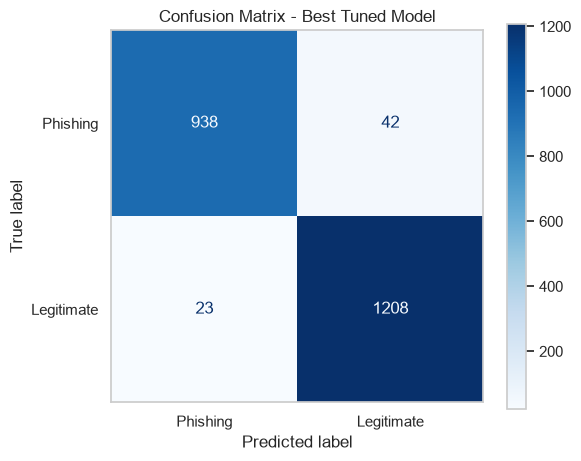

In [8]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Phishing", "Legitimate"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Best Tuned Model")
plt.grid(False)
plt.show()

## 9. Model Export

We serialize and export the trained model pipeline (which includes the scaler and the classifier) to a pickle file for deployment or downstream inference.


In [9]:
# Create model artifacts folder
save_file_path = "./phishing_classifier.pkl"

# Export pipeline using pickle
with open(save_file_path, "wb") as file:
    pickle.dump(best_pipeline, file)

print(f"Best model pipeline successfully exported to: {save_file_path}")

Best model pipeline successfully exported to: ./phishing_classifier.pkl
